In [1]:

import pandas as pd

In [2]:
train_identity=pd.read_csv("../data/raw/train_identity.csv")
train_transaction=pd.read_csv("../data/raw/train_transaction.csv")

In [3]:
train_identity.shape

(144233, 41)

In [4]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [5]:
train_transaction.shape

(590540, 394)

In [6]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
merged_df = pd.merge(train_transaction, train_identity, on="TransactionID", how="left")

In [8]:
print(merged_df.shape)

(590540, 434)


In [9]:
memory_used=merged_df.memory_usage(deep=True).sum()
print("Memory usage: ", memory_used, "bytes")
print("Memory usage: ", memory_used/(1024**2), "MB")

Memory usage:  2080582559 bytes
Memory usage:  1984.1981496810913 MB


In [10]:
merged_df.info

<bound method DataFrame.info of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ...                

In [11]:
merged_df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [12]:
merged_df.dtypes

TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD             str
                   ...   
id_36                 str
id_37                 str
id_38                 str
DeviceType            str
DeviceInfo            str
Length: 434, dtype: object

In [13]:
float_cols=merged_df.select_dtypes(include=['float64']).columns
merged_df[float_cols]=merged_df[float_cols].astype('float32')

In [14]:
int_cols=merged_df.select_dtypes(include=['int64']).columns
for cols in int_cols:
    merged_df[cols]=pd.to_numeric(merged_df[cols],downcast='integer')

In [15]:
text_cols=merged_df.select_dtypes(include=['object']).columns
merged_df[text_cols]=merged_df[text_cols].astype('category')

C:\Users\ACER\AppData\Local\Temp\ipykernel_16356\2285139049.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols=merged_df.select_dtypes(include=['object']).columns


In [16]:
memory_after=merged_df.memory_usage(deep=True).sum()
print("Memory usage after optimization: ", memory_after, "bytes")
print("Memory usage after optimization: ", memory_after/(1024**2), "MB")

Memory usage after optimization:  969132304 bytes
Memory usage after optimization:  924.2365875244141 MB


In [17]:
from pathlib import Path

# Build the path to Data/interim, creating the folder if it doesn't exist
interim_dir = Path("../Data/interim")

output_path = interim_dir / "train_merged.parquet"

# Save the merged, downcasted DataFrame
output_path.parent.mkdir(parents=True, exist_ok=True)
merged_df.to_parquet(output_path, engine="pyarrow", index=False)

print(f"Saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / (1024**2):.2f} MB")

Saved to: ..\Data\interim\train_merged.parquet
File size: 80.17 MB


In [18]:
import pandas as pd
new=pd.read_parquet("../Data/interim/train_merged.parquet")

In [19]:
new.shape

(590540, 434)

In [20]:
# Add src/ to Python's search path so it can find the fraud_triage package
import sys
sys.path.append("../src")

from fraud_triage.data.load import load_and_merge_raw_data

merged_df = load_and_merge_raw_data()
merged_df.shape

D:\Fraud-Triage\fraud-triage\src\fraud_triage\data\load.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["day"] = merged_df["TransactionDT"] // (24 * 60 * 60)


Saved to: D:\Fraud-Triage\fraud-triage\Data\interim\train_merged.parquet
Shape: (590540, 435)
File size: 80.17 MB


(590540, 435)

In [21]:
isFraud_count=merged_df['isFraud'].value_counts()
isFraud_percent=merged_df['isFraud'].value_counts(normalize=True)*100

print(f"is fraud counts:\n{isFraud_count}")
print(f"is fraud percentage:\n{isFraud_percent}")

is fraud counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64
is fraud percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


C:\Users\ACER\AppData\Local\Temp\ipykernel_16356\772068419.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df['Time_week']=merged_df['TransactionDT']//(60*60*24*7)


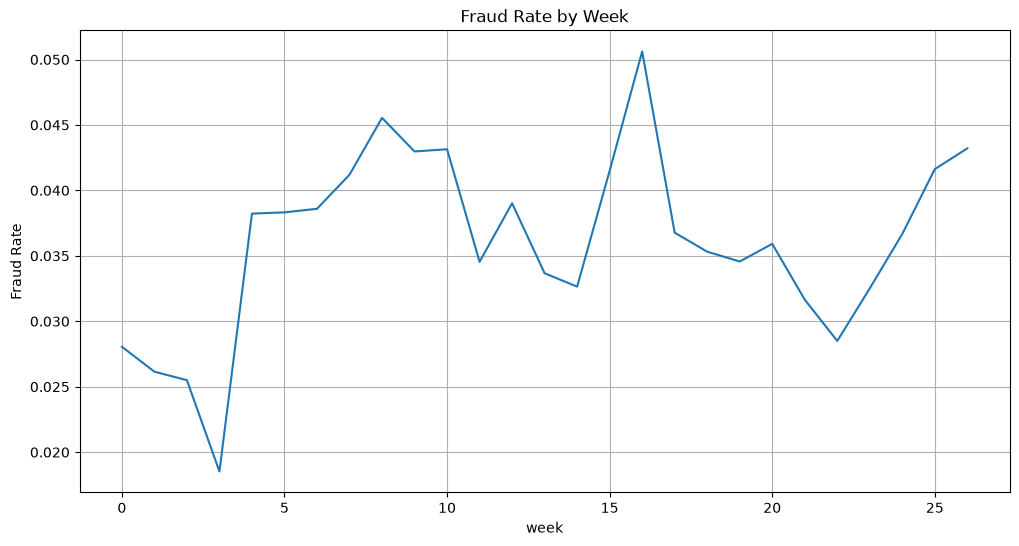

In [23]:
import matplotlib.pyplot as plt

merged_df['Time_week']=merged_df['TransactionDT']//(60*60*24*7)

fraud_rate_by_week=merged_df.groupby('Time_week')['isFraud'].mean()

plt.figure(figsize=(12,6))
plt.plot(fraud_rate_by_week.index,fraud_rate_by_week.values)
plt.title('Fraud Rate by Week')
plt.xlabel('week')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()


<Axes: title={'center': 'Fraud rate by day'}, xlabel='day'>

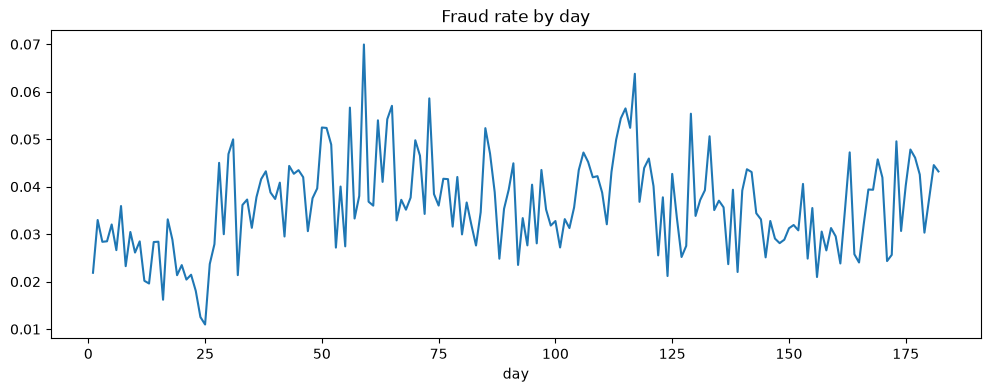

In [24]:
merged_df["day"] = merged_df["TransactionDT"] // (24 * 60 * 60)
daily_fraud_rate = merged_df.groupby("day")["isFraud"].mean()
daily_fraud_rate.plot(figsize=(12, 4), title="Fraud rate by day")

In [25]:
merged_df.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511658,239.395081,0.251,43.970001,68.5,120.0,31937.390625
1,20663.0,149.244766,232.212158,0.292,35.043999,75.0,161.0,5191.000000


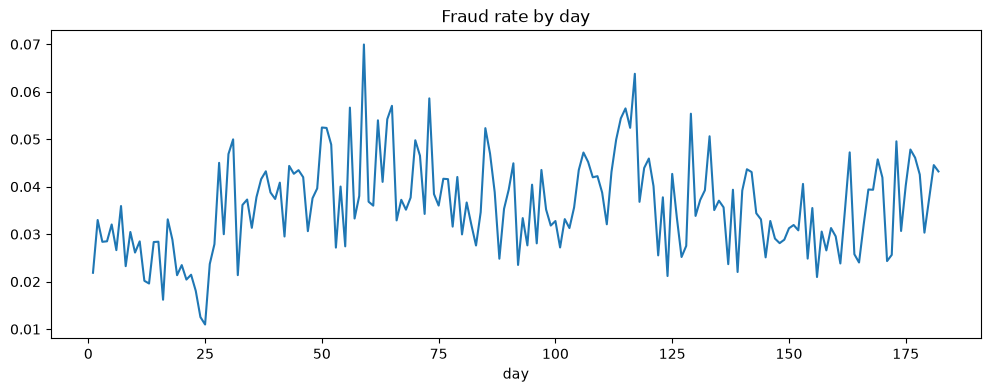

In [26]:
import matplotlib.pyplot as plt

daily_fraud_rate.plot(figsize=(12, 4), title="Fraud rate by day")
plt.savefig("../reports/figures/fraud_rate_by_day.png", bbox_inches="tight")
plt.show()

In [27]:
overall_fraud_rate=merged_df['isFraud'].mean()*100
print(f"Overall fraud rate: {overall_fraud_rate:.2f}%")

Overall fraud rate: 3.50%


In [28]:
product_fraud_rate=merged_df.groupby('ProductCD')['isFraud'].agg(['count','mean']).reset_index()
product_fraud_rate["fraud_rate"]=product_fraud_rate["mean"]*100
product_fraud_rate=product_fraud_rate.drop(columns=['mean'])
print(product_fraud_rate)

  ProductCD   count  fraud_rate
0         C   68519   11.687269
1         H   33024    4.766231
2         R   37699    3.782594
3         S   11628    5.899553
4         W  439670    2.039939


In [29]:
card6_fraud=merged_df.groupby('card6')['isFraud'].agg(['count','mean']).reset_index()
card6_fraud["fraud_rate"]=card6_fraud["mean"]*100
card6_fraud=card6_fraud.drop(columns=['mean'])
print(card6_fraud)

             card6   count  fraud_rate
0      charge card      15    0.000000
1           credit  148986    6.678480
2            debit  439938    2.426251
3  debit or credit      30    0.000000


In [30]:
card4=merged_df.groupby('card4')['isFraud'].agg(['count','mean']).reset_index()
card4['fraud_rate']=card4['mean']*100
card4=card4.drop(columns=['mean'])
print(card4)

              card4   count  fraud_rate
0  american express    8328    2.869837
1          discover    6651    7.728161
2        mastercard  189217    3.433095
3              visa  384767    3.475610


In [31]:
email_fraud = (
    merged_df.groupby("P_emaildomain")["isFraud"]
    .agg(["count", "mean"])
    .reset_index()
)

email_fraud["fraud_rate"] = email_fraud["mean"] * 100

email_fraud = email_fraud.drop(columns="mean")

print(email_fraud)

       P_emaildomain   count  fraud_rate
0            aim.com     315   12.698413
1      anonymous.com   36998    2.321747
2            aol.com   28289    2.181060
3            att.net    4033    0.743863
4      bellsouth.net    1909    2.776323
5       cableone.net     159    1.886792
6    centurylink.net     205    0.000000
7         cfl.rr.com     172    0.000000
8        charter.net     816    3.063725
9        comcast.net    7888    3.118661
10           cox.net    1393    2.081838
11     earthlink.net     514    2.140078
12    embarqmail.com     260    3.461538
13      frontier.com     280    2.857143
14   frontiernet.net     195    2.564103
15             gmail     496    2.217742
16         gmail.com  228355    4.354185
17            gmx.de     149    0.000000
18     hotmail.co.uk     112    0.000000
19       hotmail.com   45250    5.295028
20        hotmail.de      43    0.000000
21        hotmail.es     305    6.557377
22        hotmail.fr     295    0.000000
23        icloud

In [32]:
device_fraud = (
    merged_df.groupby("DeviceType")["isFraud"]
    .agg(["count", "mean"])
    .reset_index()
)

device_fraud["fraud_rate"] = device_fraud["mean"] * 100

device_fraud = device_fraud.drop(columns="mean")

print(device_fraud)

  DeviceType  count  fraud_rate
0    desktop  85165    6.521458
1     mobile  55645   10.166232


In [33]:
missing_pct = merged_df.isnull().mean()*100

print(missing_pct.sort_values(ascending=False))

id_24            99.196159
id_25            99.130965
id_08            99.127070
id_07            99.127070
id_21            99.126393
                   ...    
TransactionDT     0.000000
isFraud           0.000000
TransactionID     0.000000
day               0.000000
Time_week         0.000000
Length: 436, dtype: float64


In [34]:
families = ["C", "D", "V", "id_", "M"]

for family in families:
    cols = [col for col in merged_df.columns if col.startswith(family)]
    
    if cols:
        missing = merged_df[cols].isna().mean().mean() * 100
        
        print(f"{family}* : {missing:.2f}% missing")

C* : 0.00% missing
D* : 60.49% missing
V* : 43.04% missing
id_* : 84.82% missing
M* : 49.92% missing


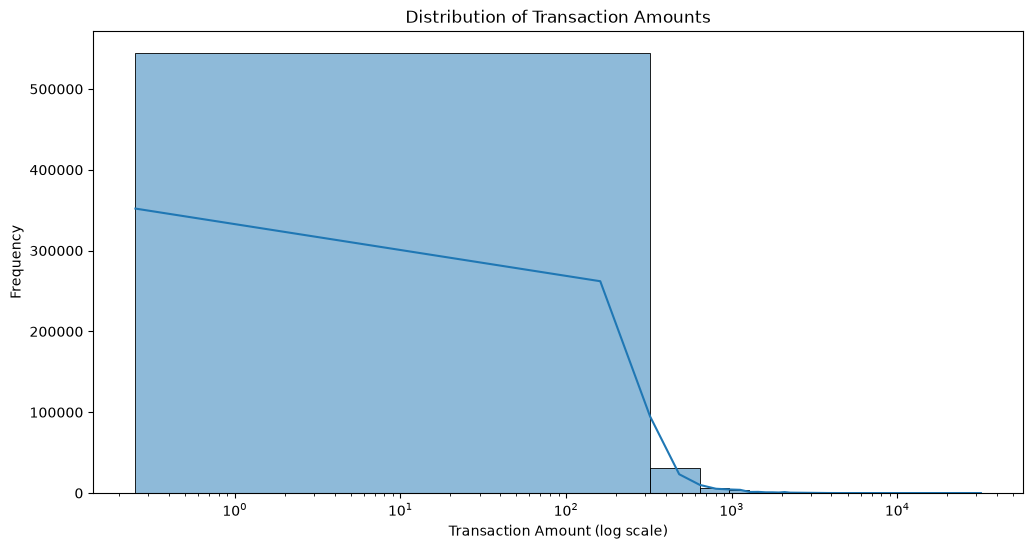

In [36]:
import seaborn as sns


plt.figure(figsize=(12,6))
plt.title('Distribution of Transaction Amounts')
sns.histplot(merged_df['TransactionAmt'],bins=100,kde=True)

plt.xscale('log')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

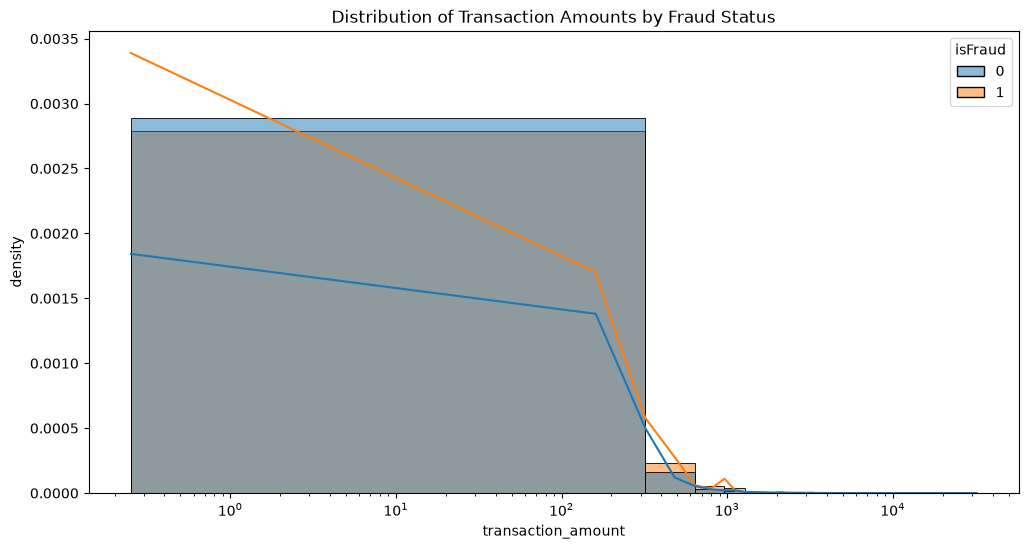

In [37]:
plt.figure(figsize=(12,6))
plt.title('Distribution of Transaction Amounts by Fraud Status')
sns.histplot(data=merged_df,x="TransactionAmt",hue="isFraud",bins=100,kde=True,stat="density",common_norm=False)
plt.xscale('log')
plt.xlabel("transaction_amount")
plt.ylabel("density")
plt.show()

In [38]:
import os

os.makedirs("../reports/figures", exist_ok=True)

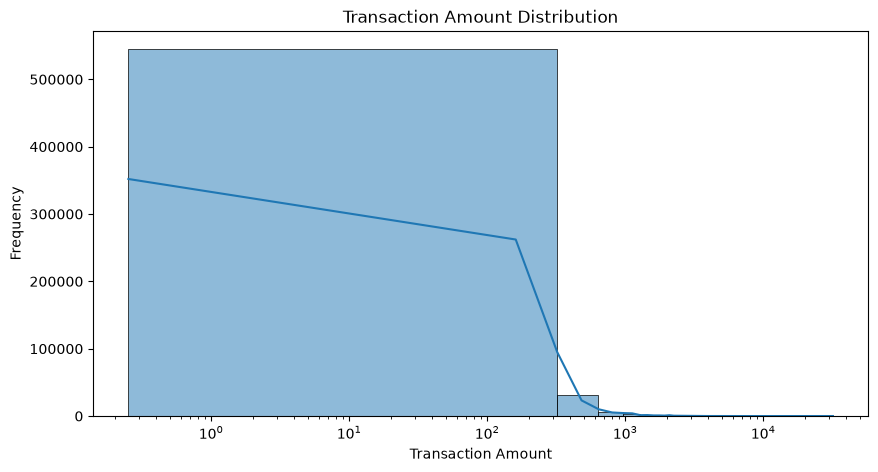

In [39]:
from pathlib import Path

plt.figure(figsize=(10, 5))

sns.histplot(
    merged_df["TransactionAmt"],
    bins=100,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.xscale("log")

figure_path = Path("../reports/figures/transaction_amount_distribution.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
from fraud_triage.data.load import load_and_merge_raw_data

merged_df = load_and_merge_raw_data()

D:\Fraud-Triage\fraud-triage\src\fraud_triage\data\load.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["day"] = merged_df["TransactionDT"] // (24 * 60 * 60)


Saved to: D:\Fraud-Triage\fraud-triage\Data\interim\train_merged.parquet
Shape: (590540, 435)
File size: 80.17 MB


In [41]:
merged_df["day"] = merged_df["TransactionDT"] // (24 * 60 * 60)

In [42]:
import sys
sys.path.append("../src")
from fraud_triage.data.split import time_based_split

train_df, val_df = time_based_split(merged_df)

Train: (440018, 435) Fraud rate: 0.03500993141189679
Val:   (142545, 435) Fraud rate: 0.03457153881230489


In [43]:
print(merged_df.columns.tolist())

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [44]:
"day" in merged_df.columns

True

In [ ]:
import sys
sys.path.append("../src")
from fraud_triage.data.split import time_based_split

train_df, val_df = time_based_split(merged_df)

Train: (440018, 435) Fraud rate: 0.03500993141189679
Val:   (142545, 435) Fraud rate: 0.03457153881230489


: 